In [1]:
!pip install --user ipympl
!pip install --user --upgrade jupyter matplotlib
!pip install --user scipy
from scipy.ndimage import uniform_filter


# Configuration cell (run SECOND)
import matplotlib
matplotlib.use('module://ipympl.backend_nbagg')  # VS Code specific backend
%matplotlib widget


import pandas as pd
import numpy as np
import matplotlib
import os
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from pathlib import Path
from helpers.load import *

scenario_parent_folder = Path(os.path.abspath('')) / 'logs' /  'unified' / 'p2p'

Ran with 
```
# Independent variables
independent_vars = {
    "nodeXCount" : [1],
    "nodeXSpacing": [1],
    "nodeXOffset": list(np.arange(0, 1.5, 0.05)) + list(np.arange(1.5, 1.9, 0.01)) + list(np.arange(1.9, 2.3, 0.05)),
    "nodeYCount" : [1],
    "nodeYSpacing": [1],
    "nodeYOffset": [0],
    "nodeZCount": [1],
    "nodeZSpacing": [1],
    "nodeZOffset": [0],
    "auvSpeed": [0],
    "propagationModel": ["underwater"],
    "waterTemperature": list(np.arange(0, 30)),
    "waterSalinity": [0.01, 0.5],
    "stopTime": [10*60],  # seconds
    "channelWidth": [1, 2],
    "scenarioFolderPath": ["\"unified/p2p/run\""]
}

# Dependent variables defined via lambda functions. 
# Each lambda receives a dict with the current independent variables.
dependent_vars = {
    "dataRatePHY": lambda args: "OfdmRate1_2MbpsBW1MHz" if args["channelWidth"] == 1 else "OfdmRate7_8MbpsBW2MHz",
}
```

In [2]:
def read_sim_config_file(scenario_folder:Path) -> dict:
    sim_config = {}
    with open(scenario_folder / 'SimConfig.txt') as f:
        for line in f:
            if line.startswith('--'):
                key, value = line.strip().split('=')
                key = key[2:]  # Remove the leading '--'
                
                # Try to convert value to appropriate data type
                try:
                    # First try as int
                    sim_config[key] = int(value)
                except ValueError:
                    try:
                        # Then try as float
                        sim_config[key] = float(value)
                    except ValueError:
                        # Keep as string if not numeric
                        sim_config[key] = value
    return sim_config

In [4]:
# Get all the scenario folders
scenario_folders = sorted([x for x in scenario_parent_folder.iterdir() if x.is_dir()])
print(f"Will load {len(scenario_folders)} scenario runs")

packet_flow_stats = pd.DataFrame()
power_state_stats = pd.DataFrame()
for i, scenario_folder in enumerate(scenario_folders):
    sim_config = read_sim_config_file(scenario_folder)
    print(f"[{i+1}/{len(scenario_folders)}] Loading scenario {scenario_folder.name}")

    # Load the flow monitor stats
    if (scenario_folder / 'FlowMonitor.xml').exists():
        fm_temp_df = load_flow_monitor_xml(scenario_folder / 'FlowMonitor.xml')
        
        if not fm_temp_df.empty:
            # Take into account only STA->AP traffic
            fm_temp_df = fm_temp_df[fm_temp_df['destinationPort'] == "84"]
            
            if fm_temp_df['rxPackets'].mean() == 0:
                packet_flow_stats.loc[i, 'Throughput'] = 0
                packet_flow_stats.loc[i, 'Latency'] = np.inf
                packet_flow_stats.loc[i, 'rxBytes'] = 0

            else:
                # Assert (fm_temp_df['timeLastRxPacket'] - fm_temp_df['timeFirstTxPacket']) > 0
                # Calculate throughput per-flow
                fm_temp_df['Throughput'] = fm_temp_df['rxBytes'] * 8 / ((fm_temp_df['timeLastRxPacket'] - fm_temp_df['timeFirstTxPacket']) / 1e9) * (1 / 10**6)  # Mbps
                
                # assert m_temp_df['rxPackets'] > 0
                # Calculate the mean latency per-flow
                fm_temp_df['MeanLatency'] = fm_temp_df['delaySum'] / fm_temp_df['rxPackets']  # ns
                
                packet_flow_stats.loc[i, 'Throughput'] = fm_temp_df['Throughput'].mean()
                packet_flow_stats.loc[i, 'Latency'] = fm_temp_df['MeanLatency'].mean()
                packet_flow_stats.loc[i, 'rxBytes'] = fm_temp_df['rxBytes'].sum()
        else:
            print(f"FlowMonitor.xml does not contain any flows in {scenario_folder.name}")
            packet_flow_stats.loc[i, 'Throughput'] = 0
            packet_flow_stats.loc[i, 'Latency'] = np.inf
            packet_flow_stats.loc[i, 'rxBytes'] = 0
        
        for key, value in sim_config.items():
            packet_flow_stats.loc[i, key] = value
    else:
        print(f"FlowMonitor.xml not found in {scenario_folder.name}")
        
    # Load the power state stats
    if (scenario_folder / 'PowerStateStats.csv').exists():
        ps_temp_df = pd.read_csv(scenario_folder / 'PowerStateStats.csv', delimiter=';', index_col=False)
        for col in ['SLEEPTime', 'IDLETime', 'TXTime', 'RXTime', 'CCA_BUSYTime', 'SWITCHINGTime', 'SLEEPEnergy', 'IDLEEnergy', 'TXEnergy', 'RXEnergy', 'CCA_BUSYEnergy', 'SWITCHINGEnergy', 'TotalEnergy']:
            # Check if the column contains string values
            if ps_temp_df[col].dtype == 'object':
                # If strings, replace 'ns' and convert to float
                ps_temp_df[col] = ps_temp_df[col].str.replace('ns', '').astype(float)
            # Ignore the APs as we assume they are always on
            power_state_stats.loc[i, col] = ps_temp_df[ps_temp_df['NodeType'] == "STA"][col].mean()
        for key, value in sim_config.items():
            power_state_stats.loc[i, key] = value
    else:
        print(f"PowerStateStats.csv not found in {scenario_folder.name}")

Will load 9359 scenario runs
[1/9359] Loading scenario run_1744198512962520793
[2/9359] Loading scenario run_1744198512962604375
[3/9359] Loading scenario run_1744198512962685640
[4/9359] Loading scenario run_1744198512962808032
[5/9359] Loading scenario run_1744198512962859634
[6/9359] Loading scenario run_1744198512963035483
[7/9359] Loading scenario run_1744198518725854380
[8/9359] Loading scenario run_1744198518826630065
[9/9359] Loading scenario run_1744198519018989703
[10/9359] Loading scenario run_1744198519196528855
[11/9359] Loading scenario run_1744198519309819884
[12/9359] Loading scenario run_1744198519420964522
[13/9359] Loading scenario run_1744198519599570461
[14/9359] Loading scenario run_1744198519952031243
[15/9359] Loading scenario run_1744198520067891061
[16/9359] Loading scenario run_1744198520246154618
[17/9359] Loading scenario run_1744198520354873235
[18/9359] Loading scenario run_1744198520829370399
[19/9359] Loading scenario run_1744198521006266730
[20/9359] L

In [5]:
packet_flow_stats
packet_flow_stats[(packet_flow_stats['waterTemperature'] == 10) & (packet_flow_stats['nodeXOffset'] == 1.35)]

,Throughput,Latency,rxBytes,nodeXCount,nodeXSpacing,nodeXOffset,nodeYCount,nodeYSpacing,nodeYOffset,nodeZCount,nodeZSpacing,nodeZOffset,auvSpeed,propagationModel,waterTemperature,waterSalinity,stopTime,channelWidth,scenarioFolderPath,dataRatePHY
3278,0.0,inf,0.0,1.0,1.0,1.35,1.0,1.0,0.0,1.0,1.0,0.0,0.0,underwater,10.0,0.01,600.0,1.0,unified/p2p/run,OfdmRate1_2MbpsBW1MHz
3281,0.0,inf,0.0,1.0,1.0,1.35,1.0,1.0,0.0,1.0,1.0,0.0,0.0,underwater,10.0,0.01,600.0,2.0,unified/p2p/run,OfdmRate7_8MbpsBW2MHz
3283,0.0,inf,0.0,1.0,1.0,1.35,1.0,1.0,0.0,1.0,1.0,0.0,0.0,underwater,10.0,0.50,600.0,2.0,unified/p2p/run,OfdmRate7_8MbpsBW2MHz
3284,0.0,inf,0.0,1.0,1.0,1.35,1.0,1.0,0.0,1.0,1.0,0.0,0.0,underwater,10.0,0.50,600.0,1.0,unified/p2p/run,OfdmRate1_2MbpsBW1MHz


In [6]:
power_state_stats

,SLEEPTime,IDLETime,TXTime,RXTime,CCA_BUSYTime,SWITCHINGTime,SLEEPEnergy,IDLEEnergy,TXEnergy,RXEnergy,...,nodeZSpacing,nodeZOffset,auvSpeed,propagationModel,waterTemperature,waterSalinity,stopTime,channelWidth,scenarioFolderPath,dataRatePHY
0,1.543047e+11,1.940298e+11,1.710597e+11,8.060932e+10,0.0,0.0,15.2762,81.523,205.063,0.0,...,1.0,0.0,0.0,underwater,1.0,0.01,600.0,1.0,unified/p2p/run,OfdmRate1_2MbpsBW1MHz
1,1.689115e+11,2.385835e+11,9.378964e+10,9.867264e+10,42000000.0,0.0,16.7222,101.253,117.888,0.0,...,1.0,0.0,0.0,underwater,1.0,0.01,600.0,2.0,unified/p2p/run,OfdmRate7_8MbpsBW2MHz
2,1.543047e+11,1.940298e+11,1.710597e+11,8.060932e+10,0.0,0.0,15.2762,81.523,205.063,0.0,...,1.0,0.0,0.0,underwater,0.0,0.50,600.0,1.0,unified/p2p/run,OfdmRate1_2MbpsBW1MHz
3,1.689115e+11,2.385835e+11,9.378964e+10,9.867264e+10,42000000.0,0.0,16.7222,101.253,117.888,0.0,...,1.0,0.0,0.0,underwater,0.0,0.50,600.0,2.0,unified/p2p/run,OfdmRate7_8MbpsBW2MHz
4,1.543047e+11,1.940298e+11,1.710597e+11,8.060932e+10,0.0,0.0,15.2762,81.523,205.063,0.0,...,1.0,0.0,0.0,underwater,0.0,0.01,600.0,1.0,unified/p2p/run,OfdmRate1_2MbpsBW1MHz
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9354,0.000000e+00,5.706724e+11,0.000000e+00,2.928000e+10,0.0,0.0,0.0000,74.232,0.000,0.0,...,1.0,0.0,0.0,underwater,29.0,0.01,600.0,1.0,unified/p2p/run,OfdmRate1_2MbpsBW1MHz
9355,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0000,0.000,0.000,0.0,...,1.0,0.0,0.0,underwater,29.0,0.50,600.0,2.0,unified/p2p/run,OfdmRate7_8MbpsBW2MHz
9356,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0000,0.000,0.000,0.0,...,1.0,0.0,0.0,underwater,28.0,0.50,600.0,2.0,unified/p2p/run,OfdmRate7_8MbpsBW2MHz
9357,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0000,0.000,0.000,0.0,...,1.0,0.0,0.0,underwater,29.0,0.50,600.0,1.0,unified/p2p/run,OfdmRate1_2MbpsBW1MHz


Number of nans 0
rendering 1
Number of nans 0
rendering 1
missing pair: 1.8400000000000003, 12.0, which implies that the simulation failed or didn't run (FlowMonitor file non-existent)
Number of nans 1
rendering 2
Number of nans 0
rendering 2


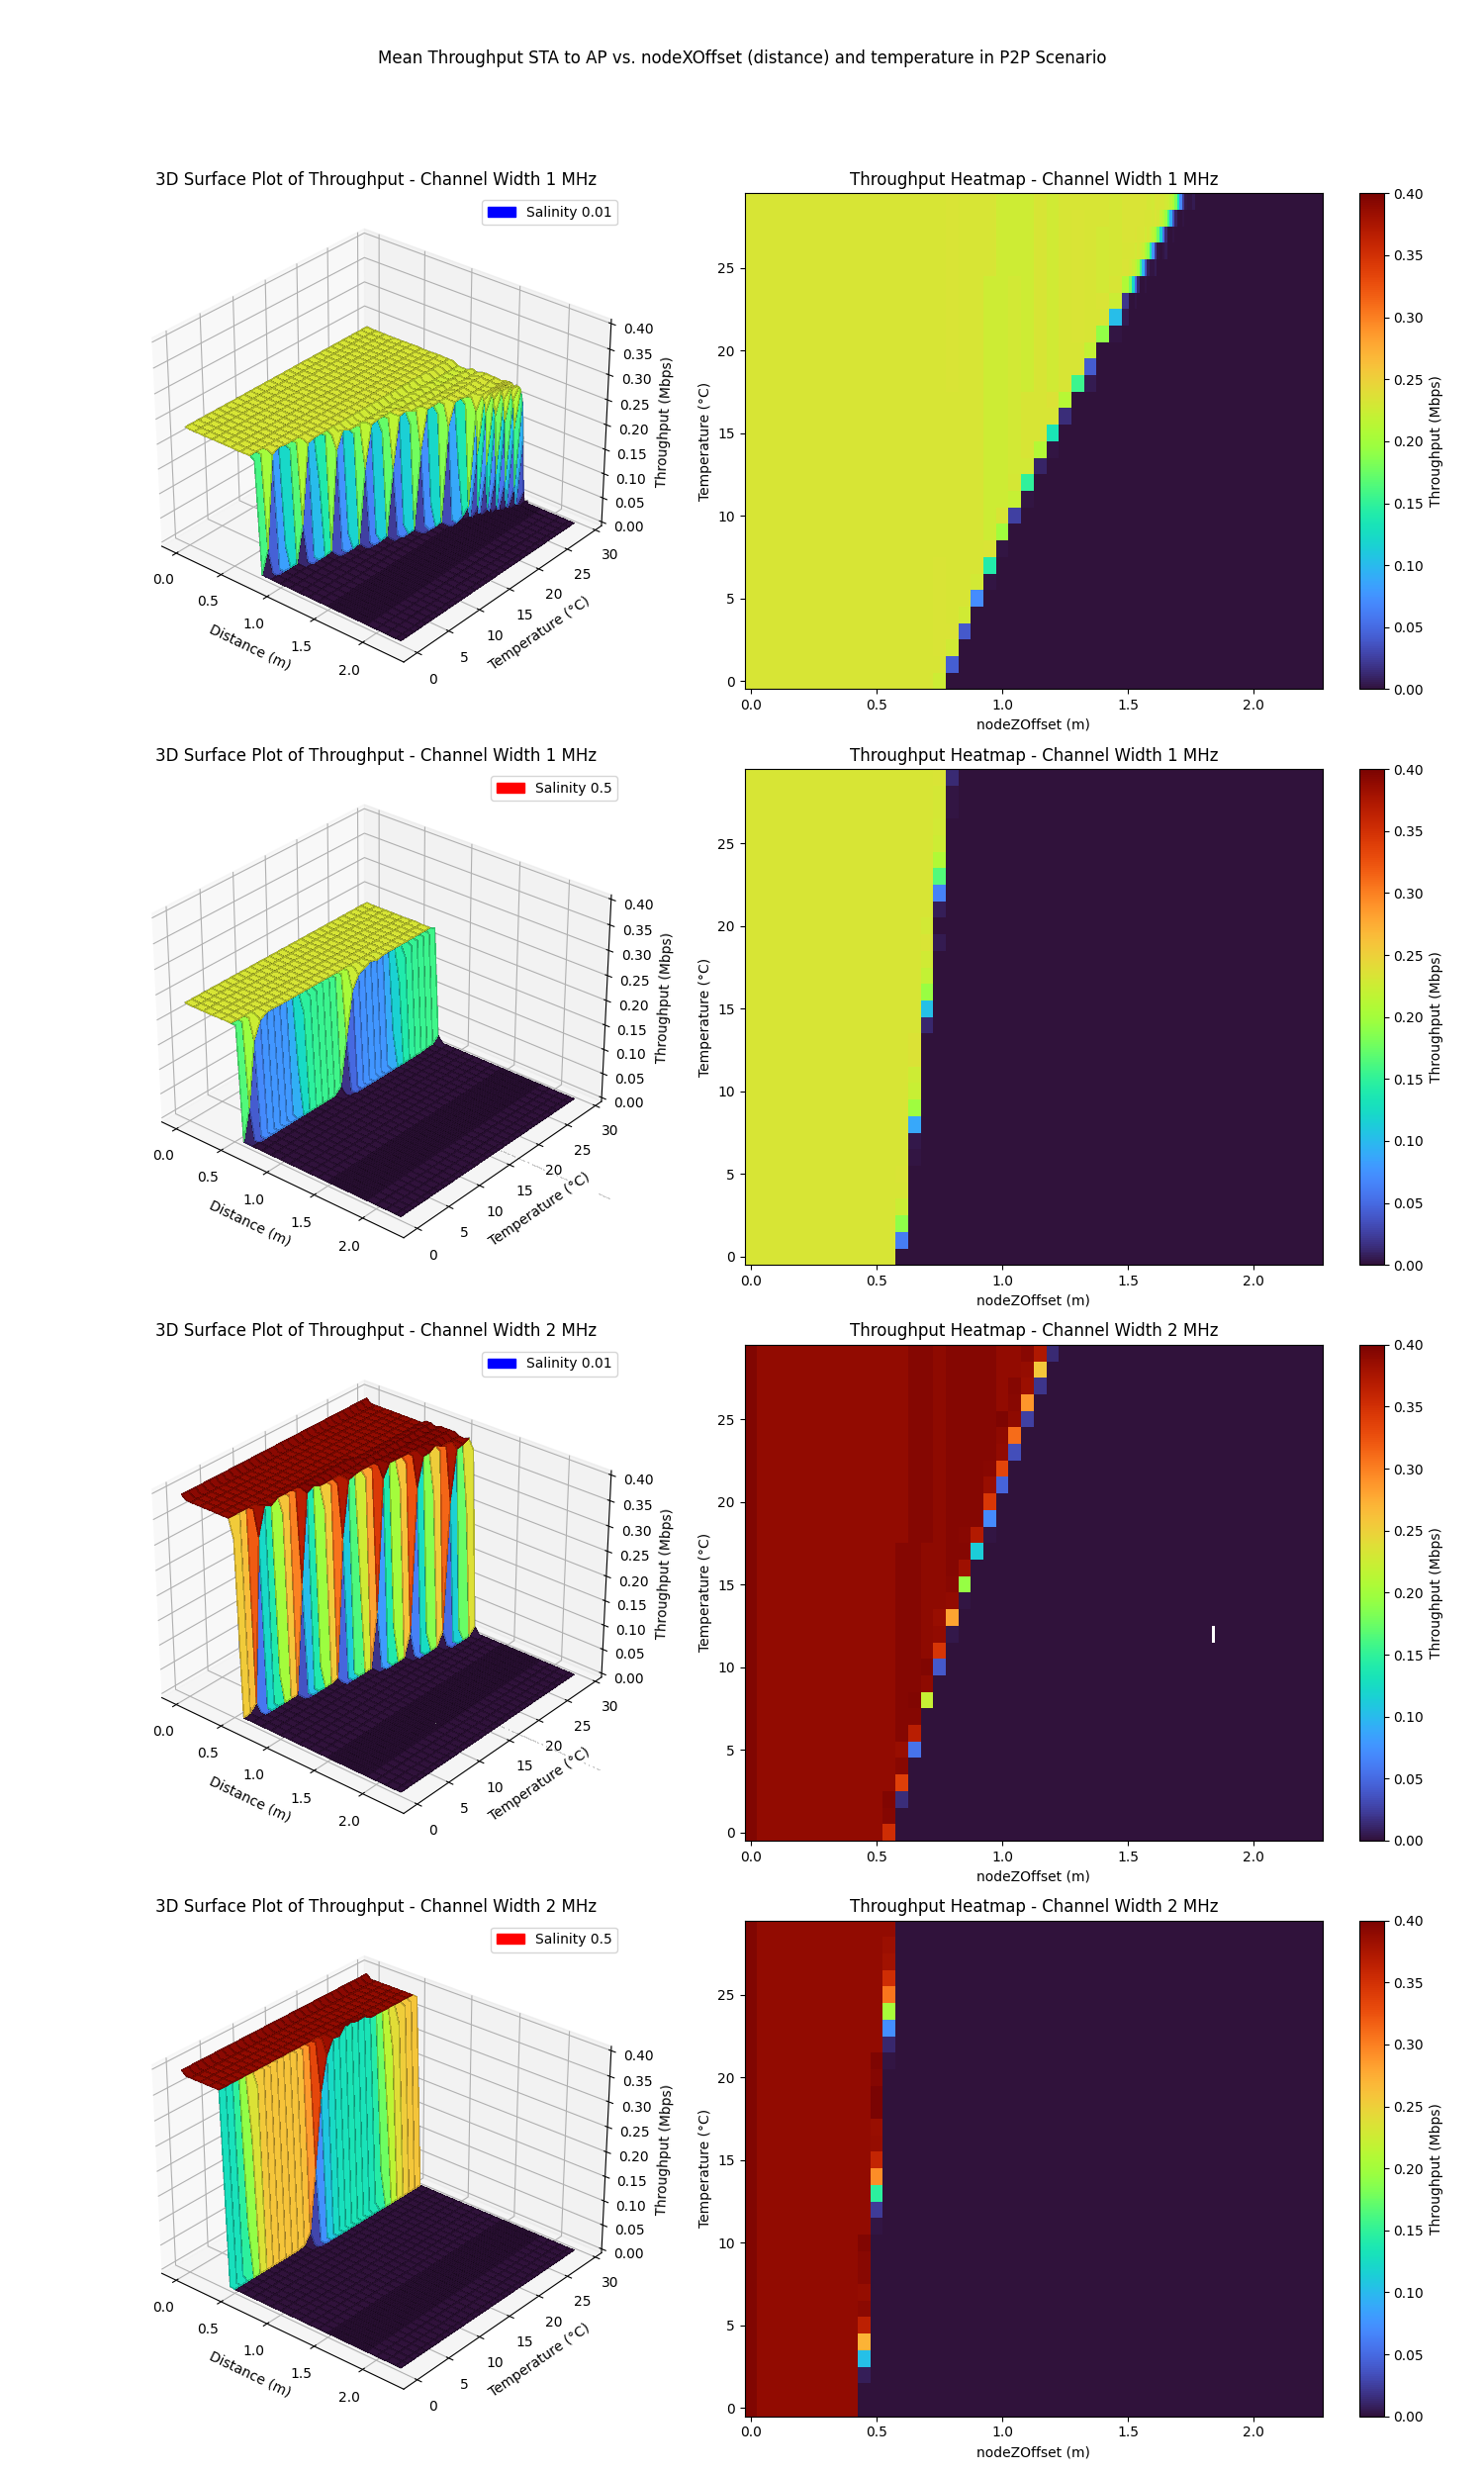

In [7]:
fig = plt.figure(figsize=(15, 25))
fig.suptitle('Mean Throughput STA to AP vs. nodeXOffset (distance) and temperature in P2P Scenario')

# Get unique values for each channel width and salinity
channel_widths = [1, 2]
salinity_values = [0.01, 0.5]

# Create a colormap for differentiating salinity
colors = ['blue', 'red']

# Process each channel width
for c_idx, channel_width in enumerate(channel_widths):
    # Filter data for this channel width
    filtered_data = packet_flow_stats[packet_flow_stats['channelWidth'] == channel_width]
    
    # # Determine the subplot positions
    # positions = [1, 2, 3] if c_idx == 0 else [4, 5, 6]
    # views = ["Isometric", "Front", "Side"]
    # elevs = [None, 0, 0]  # None = default for isometric
    # azims = [None, 0, 90]  # None = default for isometric
    
    # # Create subplots for different views
    # for i, (pos, view, elev, azim) in enumerate(zip(positions, views, elevs, azims)):

    # ax = fig.add_subplot(1, 2, c_idx + 1, projection='3d')
    
    # Plot each salinity value
    for s_idx, salinity in enumerate(salinity_values):

        #ax = fig.add_subplot(2, 2, 2*(c_idx + 1) - s_idx, projection='3d')
        ax = fig.add_subplot(4, 2, 2*s_idx + 4*c_idx + 1, projection='3d')

        # Filter data for this salinity
        salinity_data = filtered_data[filtered_data['waterSalinity'] == salinity]
        
        # Create a 2D grid for surface plot
        x_unique = np.sort(salinity_data['nodeXOffset'].unique())
        y_unique = np.sort(salinity_data['waterTemperature'].unique())
        
        X, Y = np.meshgrid(x_unique, y_unique)
        Z = np.zeros(X.shape)
        
        # Map data to grid
        for i_x in range(len(x_unique)):
            for i_y in range(len(y_unique)):
                node_x_offset = x_unique[i_x]
                node_temperature = y_unique[i_y]
                mask = (salinity_data['nodeXOffset'] == node_x_offset) & \
                        (salinity_data['waterTemperature'] == node_temperature)
                if mask.any():
                    Z[i_y, i_x] = salinity_data.loc[mask, 'Throughput'].mean()
                    if np.isnan(Z[i_y, i_x]):
                        print(f"{node_temperature}, {node_x_offset} is a NaN, which implies that something is wrong with the data")
                    else:
                        Z[i_y, i_x] = Z[i_y, i_x] #* 1e+6
                else:
                    print(f"missing pair: {node_x_offset}, {node_temperature}, which implies that the simulation failed or didn't run (FlowMonitor file non-existent)")
                    Z[i_y, i_x] = np.nan



        #Z = uniform_filter(Z, size=2)  # Adjust size for more smoothing
        # print("Z_smooth shape: ", Z.dtype)
        # print("Before smoothing:", Z)
        # print("After smoothing:", Z_smooth)
        # print("Min/Max after smoothing:", np.min(Z_smooth), np.max(Z_smooth))
        print("Number of nans", np.isnan(Z).sum())  # Count NaNs

        # epsilon = 1e-6  # Small constant to avoid log(0)
        # Z_log = np.log10(Z + epsilon)
        # Z = Z_log

        # Isometric view (default 3D view)
        print(f'rendering {c_idx + 1}')
        surf1 = ax.plot_surface(X, Y, Z, cmap='turbo',
                    edgecolor=(0,0,0,0.2),  # Lighter edges
                    linewidth=0.5,  # Thinner lines
                    antialiased=False,
                    shade=True,  # Enable shading
                    alpha=1,
                    label=f'Salinity {salinity}',
                    vmin= 0,
                    vmax= 0.4)   # For smoother surface

        ax.view_init(elev=30, azim=-50)
        # Add labels and title
        ax.set_xlabel('Distance (m)')
        ax.set_ylabel('Temperature (°C)')
        ax.set_zlabel('Throughput (Mbps)')
        ax.set_title(f'3D Surface Plot of Throughput - Channel Width {channel_width} MHz')
        ax.set_zlim(0, 0.4)


        #Overlay the actual data points
        # ax.scatter(salinity_data['nodeXOffset'], 
        #            salinity_data['waterTemperature'],
        #            salinity_data['Throughput'],
        #            color='black', s=10, label='Data Points')  # s = marker size

        
        # Add a legend
        # Hack to create a legend for the surfaces
        # Create proxy artists for legend
        proxy_artists = [plt.Rectangle((0, 0), 1, 1, color=colors[s_idx])]
        ax.legend(proxy_artists, [f'Salinity {salinity}' ], loc='upper right')
        #ax.legend(proxy_artists, [f'Salinity {salinity}'], loc='upper right')

         # --- 2D Heatmap ---
        ax2 = fig.add_subplot(4, 2, 2*s_idx + 4*c_idx + 2)  # Right side for 2D heatmap
        # Calculate edges halfway between centers
        x_edges = np.concatenate([
            [x_unique[0] - np.diff(x_unique)[0]/2],  # Left edge of first bin
            x_unique[:-1] + np.diff(x_unique)/2,      # Midpoints between centers
            [x_unique[-1] + np.diff(x_unique)[-1]/2]  # Right edge of last bin
        ])
        y_edges = np.concatenate([
            [y_unique[0] - np.diff(y_unique)[0]/2],
            y_unique[:-1] + np.diff(y_unique)/2,
            [y_unique[-1] + np.diff(y_unique)[-1]/2]
        ])

        # Create meshgrid for edges
        X_edges, Y_edges = np.meshgrid(x_edges, y_edges)

        heatmap = ax2.pcolormesh(
            X_edges,  # Grid edges (x-axis)
            Y_edges,  # Grid edges (y-axis)
            Z,  
            cmap='turbo',
            shading='flat',  # Smooths irregular grids
            antialiased= False,
            edgecolors='black',  # Avoids gaps between cells
            linewidth=0,
            vmin= 0,
            vmax= 0.4,
            rasterized= True
        )

        ax2.set_xlabel("nodeZOffset (m)")
        ax2.set_ylabel("Temperature (°C)")
        ax2.set_title(f'Throughput Heatmap - Channel Width {channel_width} MHz')
        plt.colorbar(heatmap, ax=ax2, label='Throughput (Mbps)')

        #ax2.invert_xaxis()
        #ax2.invert_yaxis()

        # Overlay the actual data points on the heatmap
        # Ensure 'x' and 'y' values are compatible with the grid from X and Y meshgrid

        #Overlay the actual data points
        # mask = (
        #     np.isfinite(salinity_data['Throughput'])
        # )
        # ax2.scatter(
        #     salinity_data.loc[mask,'nodeXOffset'],  # Filtered X values
        #     salinity_data.loc[mask, 'waterTemperature'],  # Filtered Y values 
        #     s=10, 
        #     label='Data Points'
        # )

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave room for suptitle
plt.show()

fig.savefig("P2P_Throughput_graphs.svg", format="svg", dpi=300)

Number of nans 0
rendering 1
Number of nans 0
rendering 1
missing pair: 1.8400000000000003, 12.0, which implies that the simulation failed or didn't run (FlowMonitor file non-existent)
Number of nans 1
rendering 2
Number of nans 0
rendering 2


C:\Users\20221907\AppData\Roaming\Python\Python38\site-packages\mpl_toolkits\mplot3d\proj3d.py:180: RuntimeWarning: invalid value encountered in divide
  txs, tys, tzs = vecw[0]/w, vecw[1]/w, vecw[2]/w


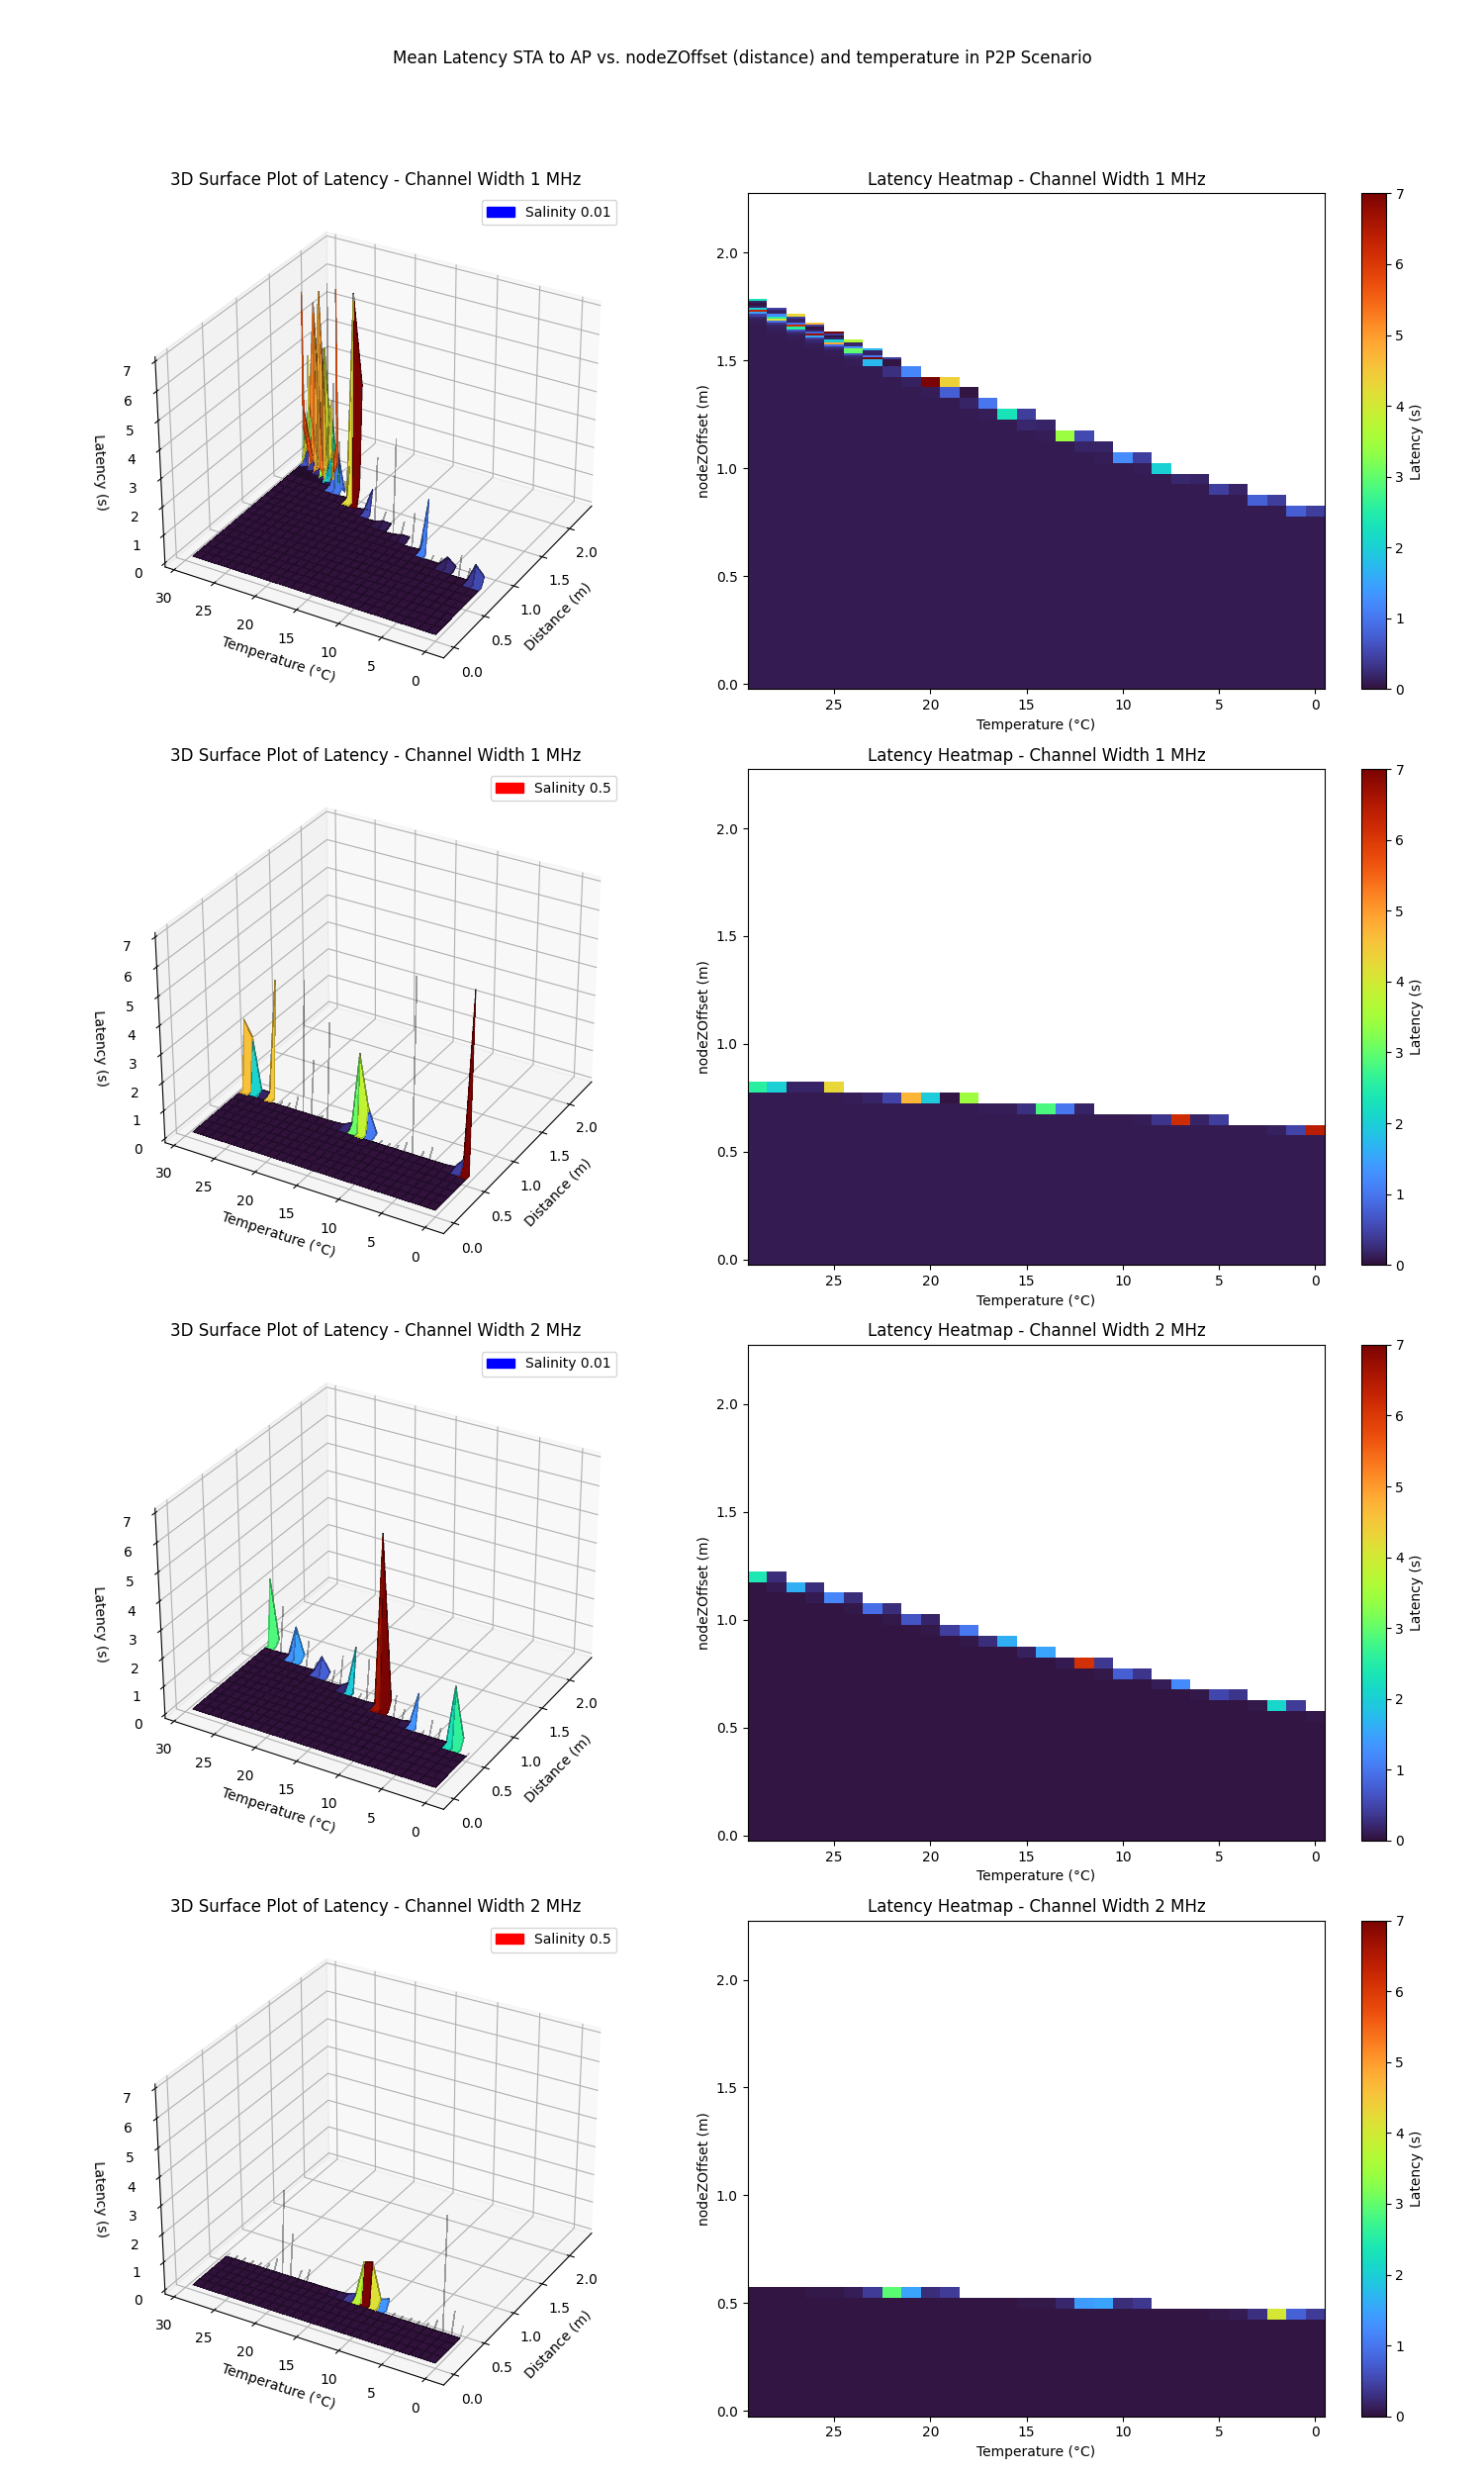

In [8]:
fig = plt.figure(figsize=(15, 25))
fig.suptitle('Mean Latency STA to AP vs. nodeZOffset (distance) and temperature in P2P Scenario')

# Get unique values for each channel width and salinity
channel_widths = [1, 2]
salinity_values = [0.01, 0.5]

# Create a colormap for differentiating salinity
colors = ['blue', 'red']

# Process each channel width
for c_idx, channel_width in enumerate(channel_widths):
    # Filter data for this channel width
    filtered_data = packet_flow_stats[packet_flow_stats['channelWidth'] == channel_width]
    
    # Plot each salinity value
    for s_idx, salinity in enumerate(salinity_values):

        #ax = fig.add_subplot(2, 2, 2*(c_idx + 1) - s_idx, projection='3d')
        ax = fig.add_subplot(4, 2, 2*s_idx + 4*c_idx + 1, projection='3d')

        # Filter data for this salinity
        salinity_data = filtered_data[filtered_data['waterSalinity'] == salinity]
        
        # Create a 2D grid for surface plot
        x_unique = np.sort(salinity_data['nodeXOffset'].unique())
        y_unique = np.sort(salinity_data['waterTemperature'].unique())
        
        X, Y = np.meshgrid(x_unique, y_unique)
        Z = np.full(X.shape, np.inf)  # Changed from np.zeros

        missing = []
        
        # Map data to grid
        for i_x in range(len(x_unique)):
            for i_y in range(len(y_unique)):
                node_x_offset = x_unique[i_x]
                node_temperature = y_unique[i_y]
                mask = (salinity_data['nodeXOffset'] == node_x_offset) & \
                        (salinity_data['waterTemperature'] == node_temperature)
                if mask.any():
                    Z[i_y, i_x] = salinity_data.loc[mask, 'Latency'].mean()
                    if np.isnan(Z[i_y, i_x]):
                        print(f"{node_temperature}, {node_x_offset} is a NaN, which implies that something is wrong with the data")
                    else:
                        Z[i_y, i_x] = Z[i_y, i_x] * 1e-9
                else:
                    print(f"missing pair: {node_x_offset}, {node_temperature}, which implies that the simulation failed or didn't run (FlowMonitor file non-existent)")
                    Z[i_y, i_x] = np.nan
                    missing.append((node_x_offset, node_temperature))

        print("Number of nans", np.isnan(Z).sum())  # Count NaNs

        # print("offset_shape", salinity_data['nodeXOffset'].shape)
        # print("temperature_shape", salinity_data['waterTemperature'].shape)
        # print("Z shape", Z.shape)

        # # Convert missing pairs to a temporary DataFrame
        # if missing:
        #     missing_df = pd.DataFrame({
        #         'nodeXOffset': [x for x, y in missing],
        #         'waterTemperature': [y for x, y in missing],
        #         'Latency': np.nan  # Fill with NaN or a default value
        #     })
        #     # Append to salinity_data (creates a new DataFrame)
        #     salinity_data = pd.concat([salinity_data, missing_df], ignore_index=True)



        # Isometric view (default 3D view)
        print(f'rendering {c_idx + 1}')
        surf1 = ax.plot_surface(X, Y, Z, cmap='turbo',
                    edgecolor=(0,0,0,0.2),  # Lighter edges
                    linewidth=0.5,  # Thinner lines
                    antialiased=False,
                    shade=True,  # Enable shading
                    alpha=1,
                    label=f'Salinity {salinity}')   # For smoother surface

        ax.view_init(elev=30, azim=210)
        # Add labels and title
        ax.set_xlabel('Distance (m)')
        ax.set_ylabel('Temperature (°C)')
        ax.set_zlabel('Latency (s)')
        ax.set_title(f'3D Surface Plot of Latency - Channel Width {channel_width} MHz')
        ax.set_zlim(0, 7)


        #Overlay the actual data points
        # ax.scatter(salinity_data['nodeXOffset'], 
        #            salinity_data['waterTemperature'],
        #            salinity_data['Latency'] * 1e-9,
        #            color='black', s=10, label='Data Points')  # s = marker size

        
        # Add a legend
        # Hack to create a legend for the surfaces
        # Create proxy artists for legend
        proxy_artists = [plt.Rectangle((0, 0), 1, 1, color=colors[s_idx])]
        ax.legend(proxy_artists, [f'Salinity {salinity}' ], loc='upper right')
        #ax.legend(proxy_artists, [f'Salinity {salinity}'], loc='upper right')

        # --- 2D Heatmap ---
        ax2 = fig.add_subplot(4, 2, 2*s_idx + 4*c_idx + 2)  # Right side for 2D heatmap
        # Calculate edges halfway between centers
        x_edges = np.concatenate([
            [x_unique[0] - np.diff(x_unique)[0]/2],  # Left edge of first bin
            x_unique[:-1] + np.diff(x_unique)/2,      # Midpoints between centers
            [x_unique[-1] + np.diff(x_unique)[-1]/2]  # Right edge of last bin
        ])
        y_edges = np.concatenate([
            [y_unique[0] - np.diff(y_unique)[0]/2],
            y_unique[:-1] + np.diff(y_unique)/2,
            [y_unique[-1] + np.diff(y_unique)[-1]/2]
        ])

        # Create meshgrid for edges
        X_edges, Y_edges = np.meshgrid(x_edges, y_edges)

        heatmap = ax2.pcolormesh(
            Y_edges, # Grid edges (x-axis)
            X_edges,  # Grid edges (y-axis)
            Z,  
            cmap='turbo',
            shading='flat',  # Smooths irregular grids
            antialiased= False,
            edgecolors='black',  # Avoids gaps between cells
            linewidth=0,
            vmin= 0,
            vmax= 7,
            rasterized= True
        )

        ax2.set_xlabel("Temperature (°C)")
        ax2.set_ylabel("nodeZOffset (m)")
        ax2.set_title(f'Latency Heatmap - Channel Width {channel_width} MHz')
        plt.colorbar(heatmap, ax=ax2, label='Latency (s)')

        ax2.invert_xaxis()
        #ax2.invert_yaxis()

        # Overlay the actual data points on the heatmap
        # Ensure 'x' and 'y' values are compatible with the grid from X and Y meshgrid

        #Overlay the actual data points
        # mask = (
        #     np.isfinite(salinity_data['Latency'])
        # )
        # ax2.scatter(
        #     salinity_data.loc[mask,'nodeXOffset'],  # Filtered X values
        #     salinity_data.loc[mask, 'waterTemperature'],  # Filtered Y values 
        #     s=10, 
        #     label='Data Points'
        # )

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave room for suptitle
plt.show()

fig.savefig("P2P_Latency_graphs.svg", format="svg", dpi=300)

In [15]:
power_state_stats['TotalPower'] = power_state_stats['TotalEnergy'] / power_state_stats['stopTime'] # Convert to W

# Merge the two dataframes on all config columns based on the last scenario folder's config
config_columns = list(sim_config.keys())
merged_stats = pd.merge(packet_flow_stats, power_state_stats, on=config_columns)

#merged_stats = merged_stats[merged_stats['rxBytes'] != 0] #keep only the nodes that connected
merged_stats

,Throughput,Latency,rxBytes,nodeXCount,nodeXSpacing,nodeXOffset,nodeYCount,nodeYSpacing,nodeYOffset,nodeZCount,...,CCA_BUSYTime,SWITCHINGTime,SLEEPEnergy,IDLEEnergy,TXEnergy,RXEnergy,CCA_BUSYEnergy,SWITCHINGEnergy,TotalEnergy,TotalPower
0,0.232365,1.016415e+08,17397852.0,1.0,1.0,0.00,1.0,1.0,0.0,1.0,...,0.0,0.0,15.2762,81.523,205.063,0.0,0.000000,0.0,301.862,0.503103
1,0.396316,4.890806e+07,29673528.0,1.0,1.0,0.00,1.0,1.0,0.0,1.0,...,42000000.0,0.0,16.7222,101.253,117.888,0.0,0.001016,0.0,235.864,0.393107
2,0.232365,1.016415e+08,17397852.0,1.0,1.0,0.00,1.0,1.0,0.0,1.0,...,0.0,0.0,15.2762,81.523,205.063,0.0,0.000000,0.0,301.862,0.503103
3,0.396316,4.890806e+07,29673528.0,1.0,1.0,0.00,1.0,1.0,0.0,1.0,...,42000000.0,0.0,16.7222,101.253,117.888,0.0,0.001016,0.0,235.864,0.393107
4,0.232365,1.016415e+08,17397852.0,1.0,1.0,0.00,1.0,1.0,0.0,1.0,...,0.0,0.0,15.2762,81.523,205.063,0.0,0.000000,0.0,301.862,0.503103
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9354,0.000000,inf,0.0,1.0,1.0,2.25,1.0,1.0,0.0,1.0,...,0.0,0.0,0.0000,74.232,0.000,0.0,0.000000,0.0,74.232,0.123720
9355,0.000000,inf,0.0,1.0,1.0,2.25,1.0,1.0,0.0,1.0,...,0.0,0.0,0.0000,0.000,0.000,0.0,0.000000,0.0,0.000,0.000000
9356,0.000000,inf,0.0,1.0,1.0,2.25,1.0,1.0,0.0,1.0,...,0.0,0.0,0.0000,0.000,0.000,0.0,0.000000,0.0,0.000,0.000000
9357,0.000000,inf,0.0,1.0,1.0,2.25,1.0,1.0,0.0,1.0,...,0.0,0.0,0.0000,0.000,0.000,0.0,0.000000,0.0,0.000,0.000000


Number of nans 0
rendering 1
Number of nans 0
rendering 1
missing pair: 1.8400000000000003, 12.0, which implies that the simulation failed or didn't run (FlowMonitor file non-existent)
Number of nans 1
rendering 2
Number of nans 0
rendering 2


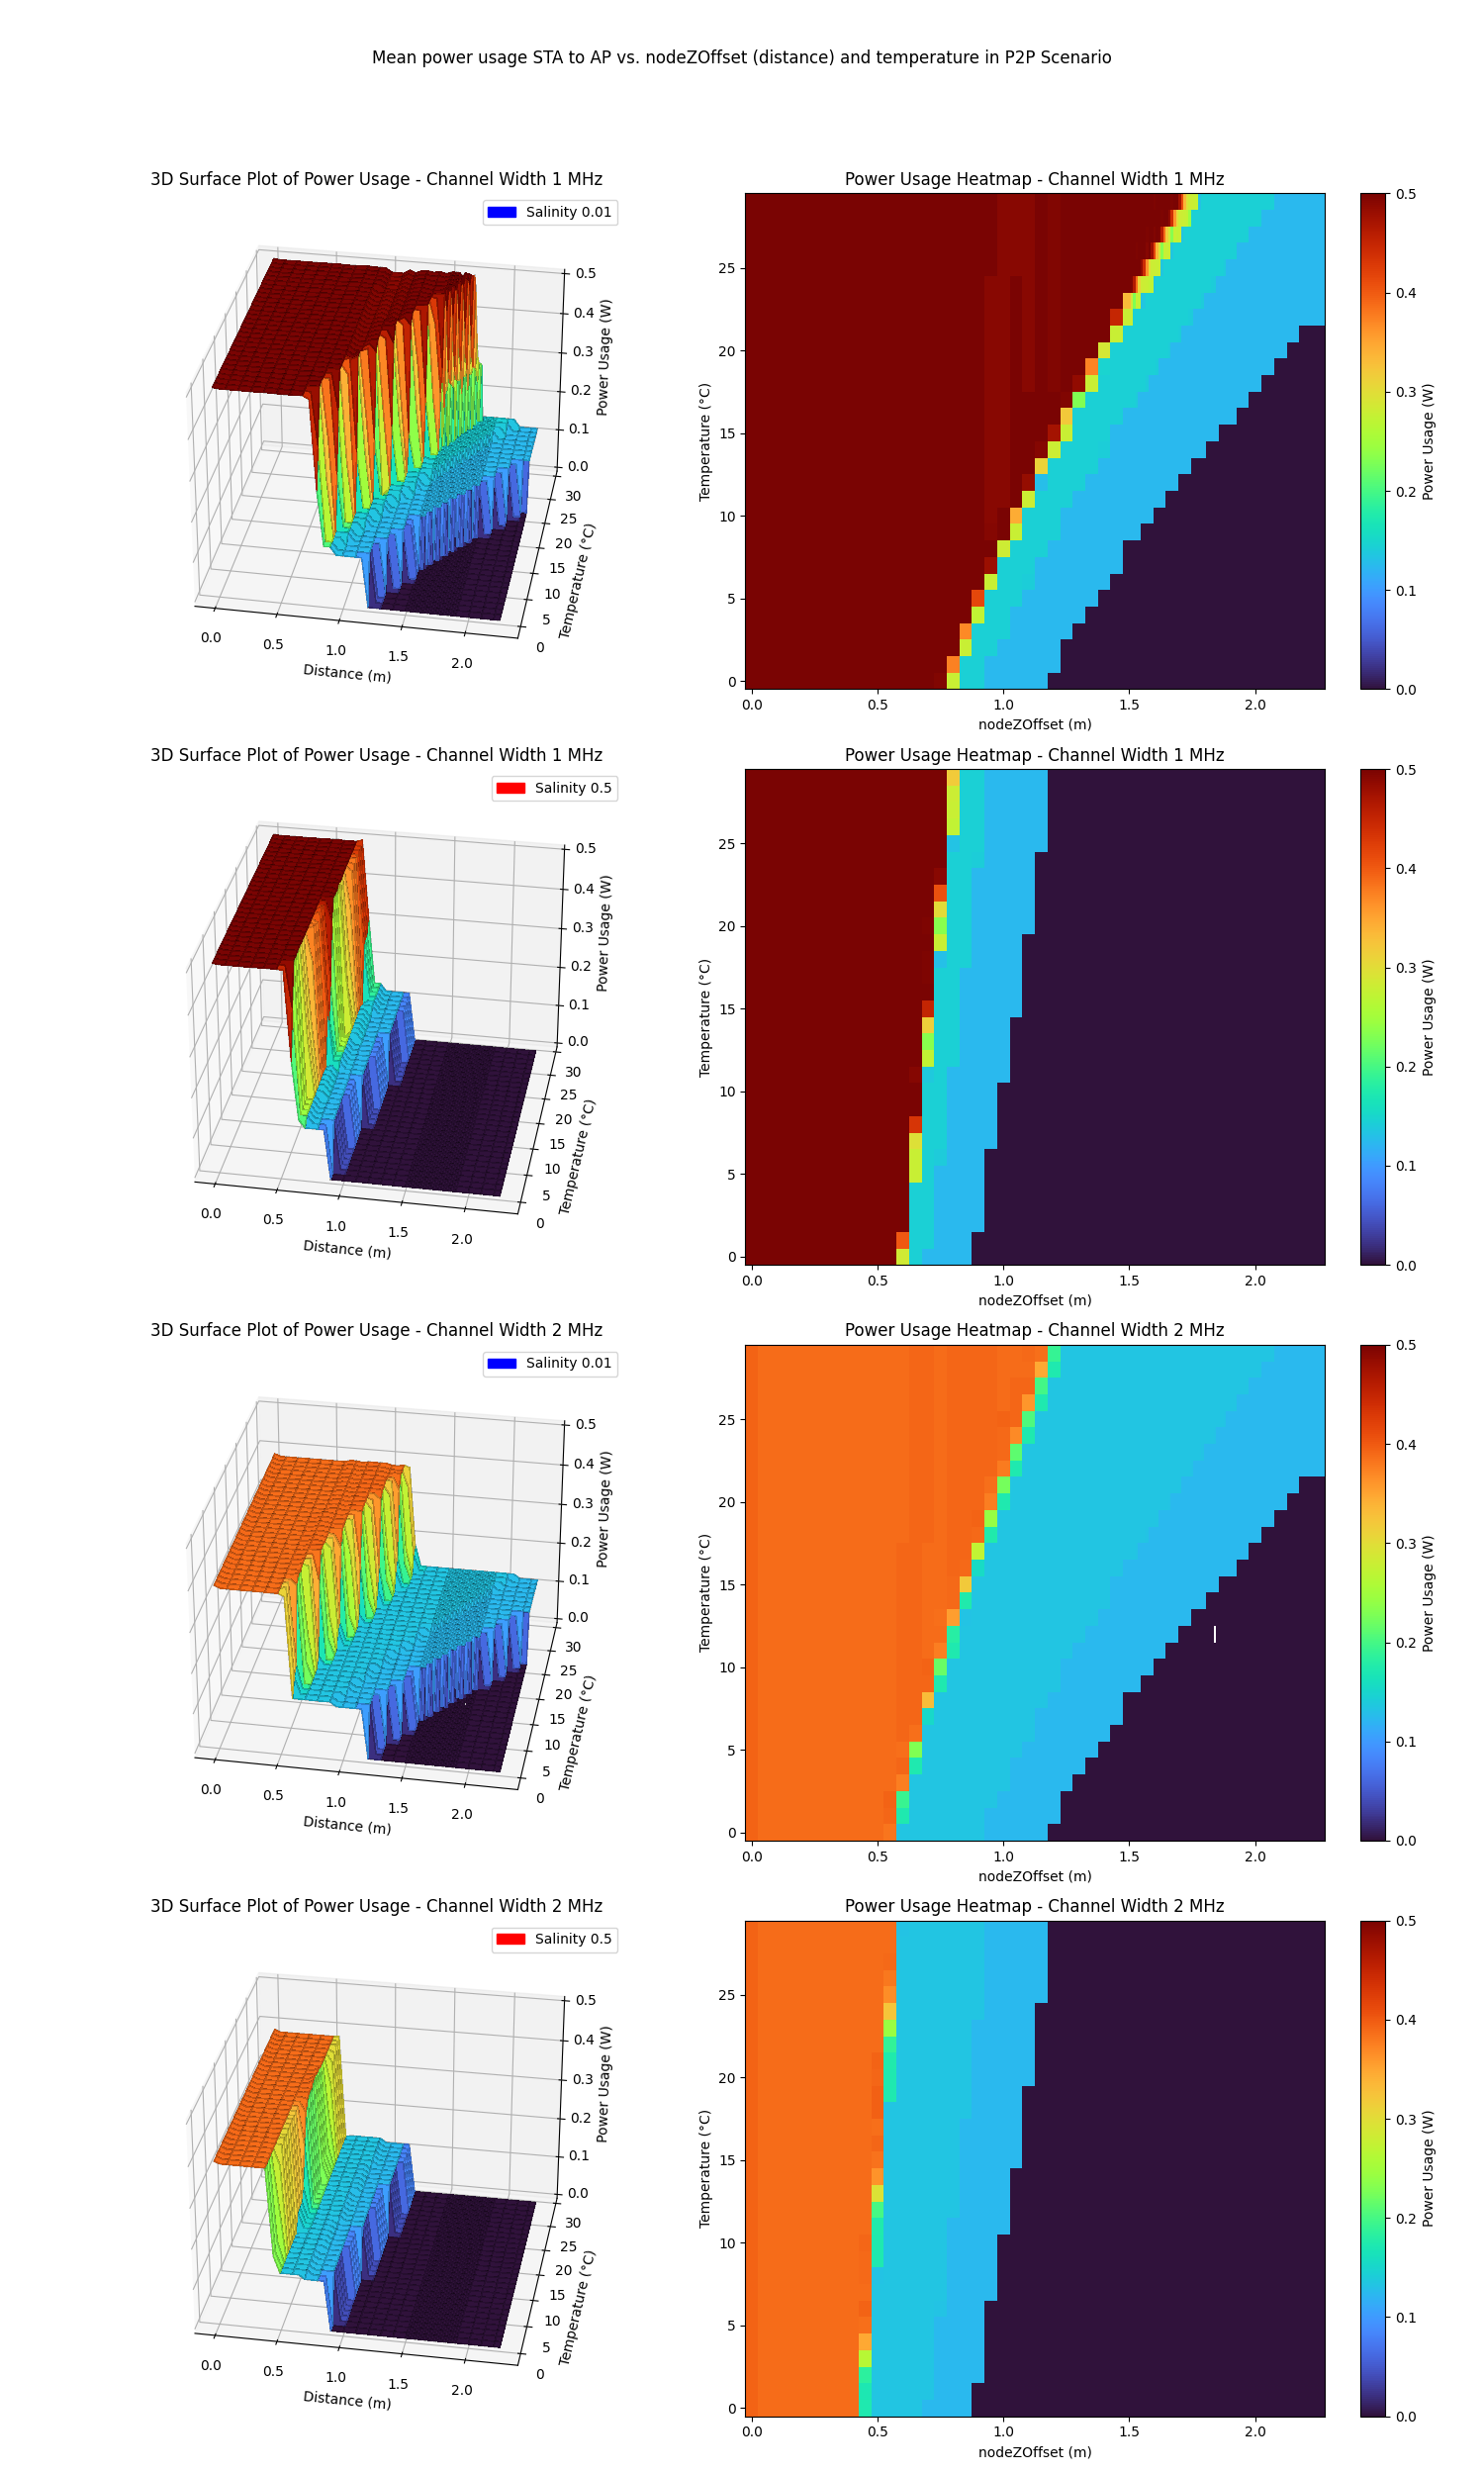

In [16]:

fig = plt.figure(figsize=(15, 25))
fig.suptitle('Mean power usage STA to AP vs. nodeZOffset (distance) and temperature in P2P Scenario')

# Get unique values for each channel width and salinity
channel_widths = [1, 2]
salinity_values = [0.01, 0.5]

# Create a colormap for differentiating salinity
colors = ['blue', 'red']

# Process each channel width
for c_idx, channel_width in enumerate(channel_widths):
    # Filter data for this channel width
    filtered_data = merged_stats[merged_stats['channelWidth'] == channel_width]
    
    # Plot each salinity value
    for s_idx, salinity in enumerate(salinity_values):

        #ax = fig.add_subplot(2, 2, 2*(c_idx + 1) - s_idx, projection='3d')
        ax = fig.add_subplot(4, 2, 2*s_idx + 4*c_idx + 1, projection='3d')

        # Filter data for this salinity
        salinity_data = filtered_data[filtered_data['waterSalinity'] == salinity]
        
        # Create a 2D grid for surface plot
        x_unique = np.sort(salinity_data['nodeXOffset'].unique())
        y_unique = np.sort(salinity_data['waterTemperature'].unique())
        
        X, Y = np.meshgrid(x_unique, y_unique)
        Z = np.full(X.shape, np.inf)  # Changed from np.zeros

        missing = []
        
        # Map data to grid
        for i_x in range(len(x_unique)):
            for i_y in range(len(y_unique)):
                node_x_offset = x_unique[i_x]
                node_temperature = y_unique[i_y]
                mask = (salinity_data['nodeXOffset'] == node_x_offset) & \
                        (salinity_data['waterTemperature'] == node_temperature)
                if mask.any():
                    Z[i_y, i_x] = salinity_data.loc[mask, 'TotalPower'].mean()
                    if np.isnan(Z[i_y, i_x]):
                        print(f"{node_temperature}, {node_x_offset} is a NaN, which implies that something is wrong with the data")
                    else:
                        Z[i_y, i_x] = Z[i_y, i_x]
                else:
                    print(f"missing pair: {node_x_offset}, {node_temperature}, which implies that the simulation failed or didn't run (FlowMonitor file non-existent)")
                    Z[i_y, i_x] = np.nan
                    missing.append((node_x_offset, node_temperature))

        print("Number of nans", np.isnan(Z).sum())  # Count NaNs

        # print("offset_shape", salinity_data['nodeXOffset'].shape)
        # print("temperature shape", salinity_data['waterTemperature'].shape)
        # print("Z shape", Z.shape)

        # # Convert missing pairs to a temporary DataFrame
        # if missing:
        #     missing_df = pd.DataFrame({
        #         'nodeXOffset': [x for x, y in missing],
        #         'waterTemperature': [y for x, y in missing],
        #         'TotalPower': np.nan  # Fill with NaN or a default value
        #     })
        #     # Append to salinity_data (creates a new DataFrame)
        #     salinity_data = pd.concat([salinity_data, missing_df], ignore_index=True)



        # Isometric view (default 3D view)
        print(f'rendering {c_idx + 1}')
        surf1 = ax.plot_surface(X, Y, Z, cmap='turbo',
                    edgecolor=(0,0,0,0.2),  # Lighter edges
                    linewidth=0.5,  # Thinner lines
                    antialiased=False,
                    shade=True,  # Enable shading
                    alpha=1,
                    label=f'Salinity {salinity}',
                    vmin= 0,
                    vmax= 0.5)   # For smoother surface

        ax.view_init(elev=30, azim=-80)
        # Add labels and title
        ax.set_xlabel('Distance (m)')
        ax.set_ylabel('Temperature (°C)')
        ax.set_zlabel('Power Usage (W)')
        ax.set_title(f'3D Surface Plot of Power Usage - Channel Width {channel_width} MHz')
        ax.set_zlim(0, 0.5)


        #Overlay the actual data points
        # ax.scatter(salinity_data['nodeXOffset'], 
        #            salinity_data['waterTemperature'],
        #            salinity_data['TotalPower'],
        #            color='black', s=10, label='Data Points')  # s = marker size

        
        # Add a legend
        # Hack to create a legend for the surfaces
        # Create proxy artists for legend
        proxy_artists = [plt.Rectangle((0, 0), 1, 1, color=colors[s_idx])]
        ax.legend(proxy_artists, [f'Salinity {salinity}' ], loc='upper right')
        #ax.legend(proxy_artists, [f'Salinity {salinity}'], loc='upper right')

        # --- 2D Heatmap ---
        ax2 = fig.add_subplot(4, 2, 2*s_idx + 4*c_idx + 2)  # Right side for 2D heatmap
        # Calculate edges halfway between centers
        x_edges = np.concatenate([
            [x_unique[0] - np.diff(x_unique)[0]/2],  # Left edge of first bin
            x_unique[:-1] + np.diff(x_unique)/2,      # Midpoints between centers
            [x_unique[-1] + np.diff(x_unique)[-1]/2]  # Right edge of last bin
        ])
        y_edges = np.concatenate([
            [y_unique[0] - np.diff(y_unique)[0]/2],
            y_unique[:-1] + np.diff(y_unique)/2,
            [y_unique[-1] + np.diff(y_unique)[-1]/2]
        ])

        # Create meshgrid for edges
        X_edges, Y_edges = np.meshgrid(x_edges, y_edges)

        heatmap = ax2.pcolormesh(
            X_edges,  # Grid edges (x-axis)
            Y_edges,  # Grid edges (y-axis)
            Z,  
            cmap='turbo',
            shading='flat',  # Smooths irregular grids
            antialiased= False,
            edgecolors='black',  # Avoids gaps between cells
            linewidth=0,
            vmin= 0,
            vmax= 0.5,
            rasterized= True
        )

        ax2.set_xlabel("nodeZOffset (m)")
        ax2.set_ylabel("Temperature (°C)")
        ax2.set_title(f'Power Usage Heatmap - Channel Width {channel_width} MHz')
        plt.colorbar(heatmap, ax=ax2, label='Power Usage (W)')


        # Overlay the actual data points on the heatmap
        # Ensure 'x' and 'y' values are compatible with the grid from X and Y meshgrid

        #Overlay the actual data points
        # mask = (
        #     np.isfinite(salinity_data['TotalPower'])
        # )
        # ax2.scatter(
        #     salinity_data.loc[mask,'nodeXOffset'],  # Filtered X values
        #     salinity_data.loc[mask, 'waterTemperature'],  # Filtered Y values 
        #     s=10, 
        #     label='Data Points'
        # )

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave room for suptitle
plt.show()

fig.savefig("P2P_Power_Usage_graphs.svg", format="svg", dpi=300)

In [11]:
# Merge the two dataframes on all config columns based on the last scenario folder's config
config_columns = list(sim_config.keys())
merged_stats = pd.merge(packet_flow_stats, power_state_stats, on=config_columns)

merged_stats["EnergyEfficiency"] = merged_stats["rxBytes"] * 8 / merged_stats["TotalEnergy"]
merged_stats = merged_stats[merged_stats['rxBytes'] != 0] #keep only the nodes that connected
merged_stats

,Throughput,Latency,rxBytes,nodeXCount,nodeXSpacing,nodeXOffset,nodeYCount,nodeYSpacing,nodeYOffset,nodeZCount,...,SWITCHINGTime,SLEEPEnergy,IDLEEnergy,TXEnergy,RXEnergy,CCA_BUSYEnergy,SWITCHINGEnergy,TotalEnergy,TotalPower,EnergyEfficiency
0,0.232365,1.016415e+08,17397852.0,1.0,1.0,0.00,1.0,1.0,0.0,1.0,...,0.0,15.27620,81.5230,205.06300,0.0,0.000000,0.0,301.8620,0.503103,4.610809e+05
1,0.396316,4.890806e+07,29673528.0,1.0,1.0,0.00,1.0,1.0,0.0,1.0,...,0.0,16.72220,101.2530,117.88800,0.0,0.001016,0.0,235.8640,0.393107,1.006462e+06
2,0.232365,1.016415e+08,17397852.0,1.0,1.0,0.00,1.0,1.0,0.0,1.0,...,0.0,15.27620,81.5230,205.06300,0.0,0.000000,0.0,301.8620,0.503103,4.610809e+05
3,0.396316,4.890806e+07,29673528.0,1.0,1.0,0.00,1.0,1.0,0.0,1.0,...,0.0,16.72220,101.2530,117.88800,0.0,0.001016,0.0,235.8640,0.393107,1.006462e+06
4,0.232365,1.016415e+08,17397852.0,1.0,1.0,0.00,1.0,1.0,0.0,1.0,...,0.0,15.27620,81.5230,205.06300,0.0,0.000000,0.0,301.8620,0.503103,4.610809e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6597,0.001915,2.016238e+09,1284.0,1.0,1.0,1.74,1.0,1.0,0.0,1.0,...,0.0,8.41254,41.8771,118.44300,0.0,0.000000,0.0,168.7330,0.281222,6.087724e+01
6716,0.001848,1.907301e+08,108.0,1.0,1.0,1.75,1.0,1.0,0.0,1.0,...,0.0,8.34696,41.8012,117.46000,0.0,0.000000,0.0,167.6090,0.279348,5.154854e+00
6837,0.005300,4.640192e+07,108.0,1.0,1.0,1.76,1.0,1.0,0.0,1.0,...,0.0,8.36579,41.9681,116.76600,0.0,0.000000,0.0,167.1000,0.278500,5.170557e+00
6955,0.000102,1.885947e+08,276.0,1.0,1.0,1.77,1.0,1.0,0.0,1.0,...,0.0,8.80816,42.4289,112.15500,0.0,0.000000,0.0,163.3920,0.272320,1.351351e+01


missing pair: 0.8500000000000001, 0.0, which implies that the simulation failed or didn't run (FlowMonitor file non-existent)
missing pair: 0.8500000000000001, 1.0, which implies that the simulation failed or didn't run (FlowMonitor file non-existent)
missing pair: 0.9, 0.0, which implies that the simulation failed or didn't run (FlowMonitor file non-existent)
missing pair: 0.9, 1.0, which implies that the simulation failed or didn't run (FlowMonitor file non-existent)
missing pair: 0.9, 2.0, which implies that the simulation failed or didn't run (FlowMonitor file non-existent)
missing pair: 0.9, 3.0, which implies that the simulation failed or didn't run (FlowMonitor file non-existent)
missing pair: 0.9500000000000001, 0.0, which implies that the simulation failed or didn't run (FlowMonitor file non-existent)
missing pair: 0.9500000000000001, 1.0, which implies that the simulation failed or didn't run (FlowMonitor file non-existent)
missing pair: 0.9500000000000001, 2.0, which implies

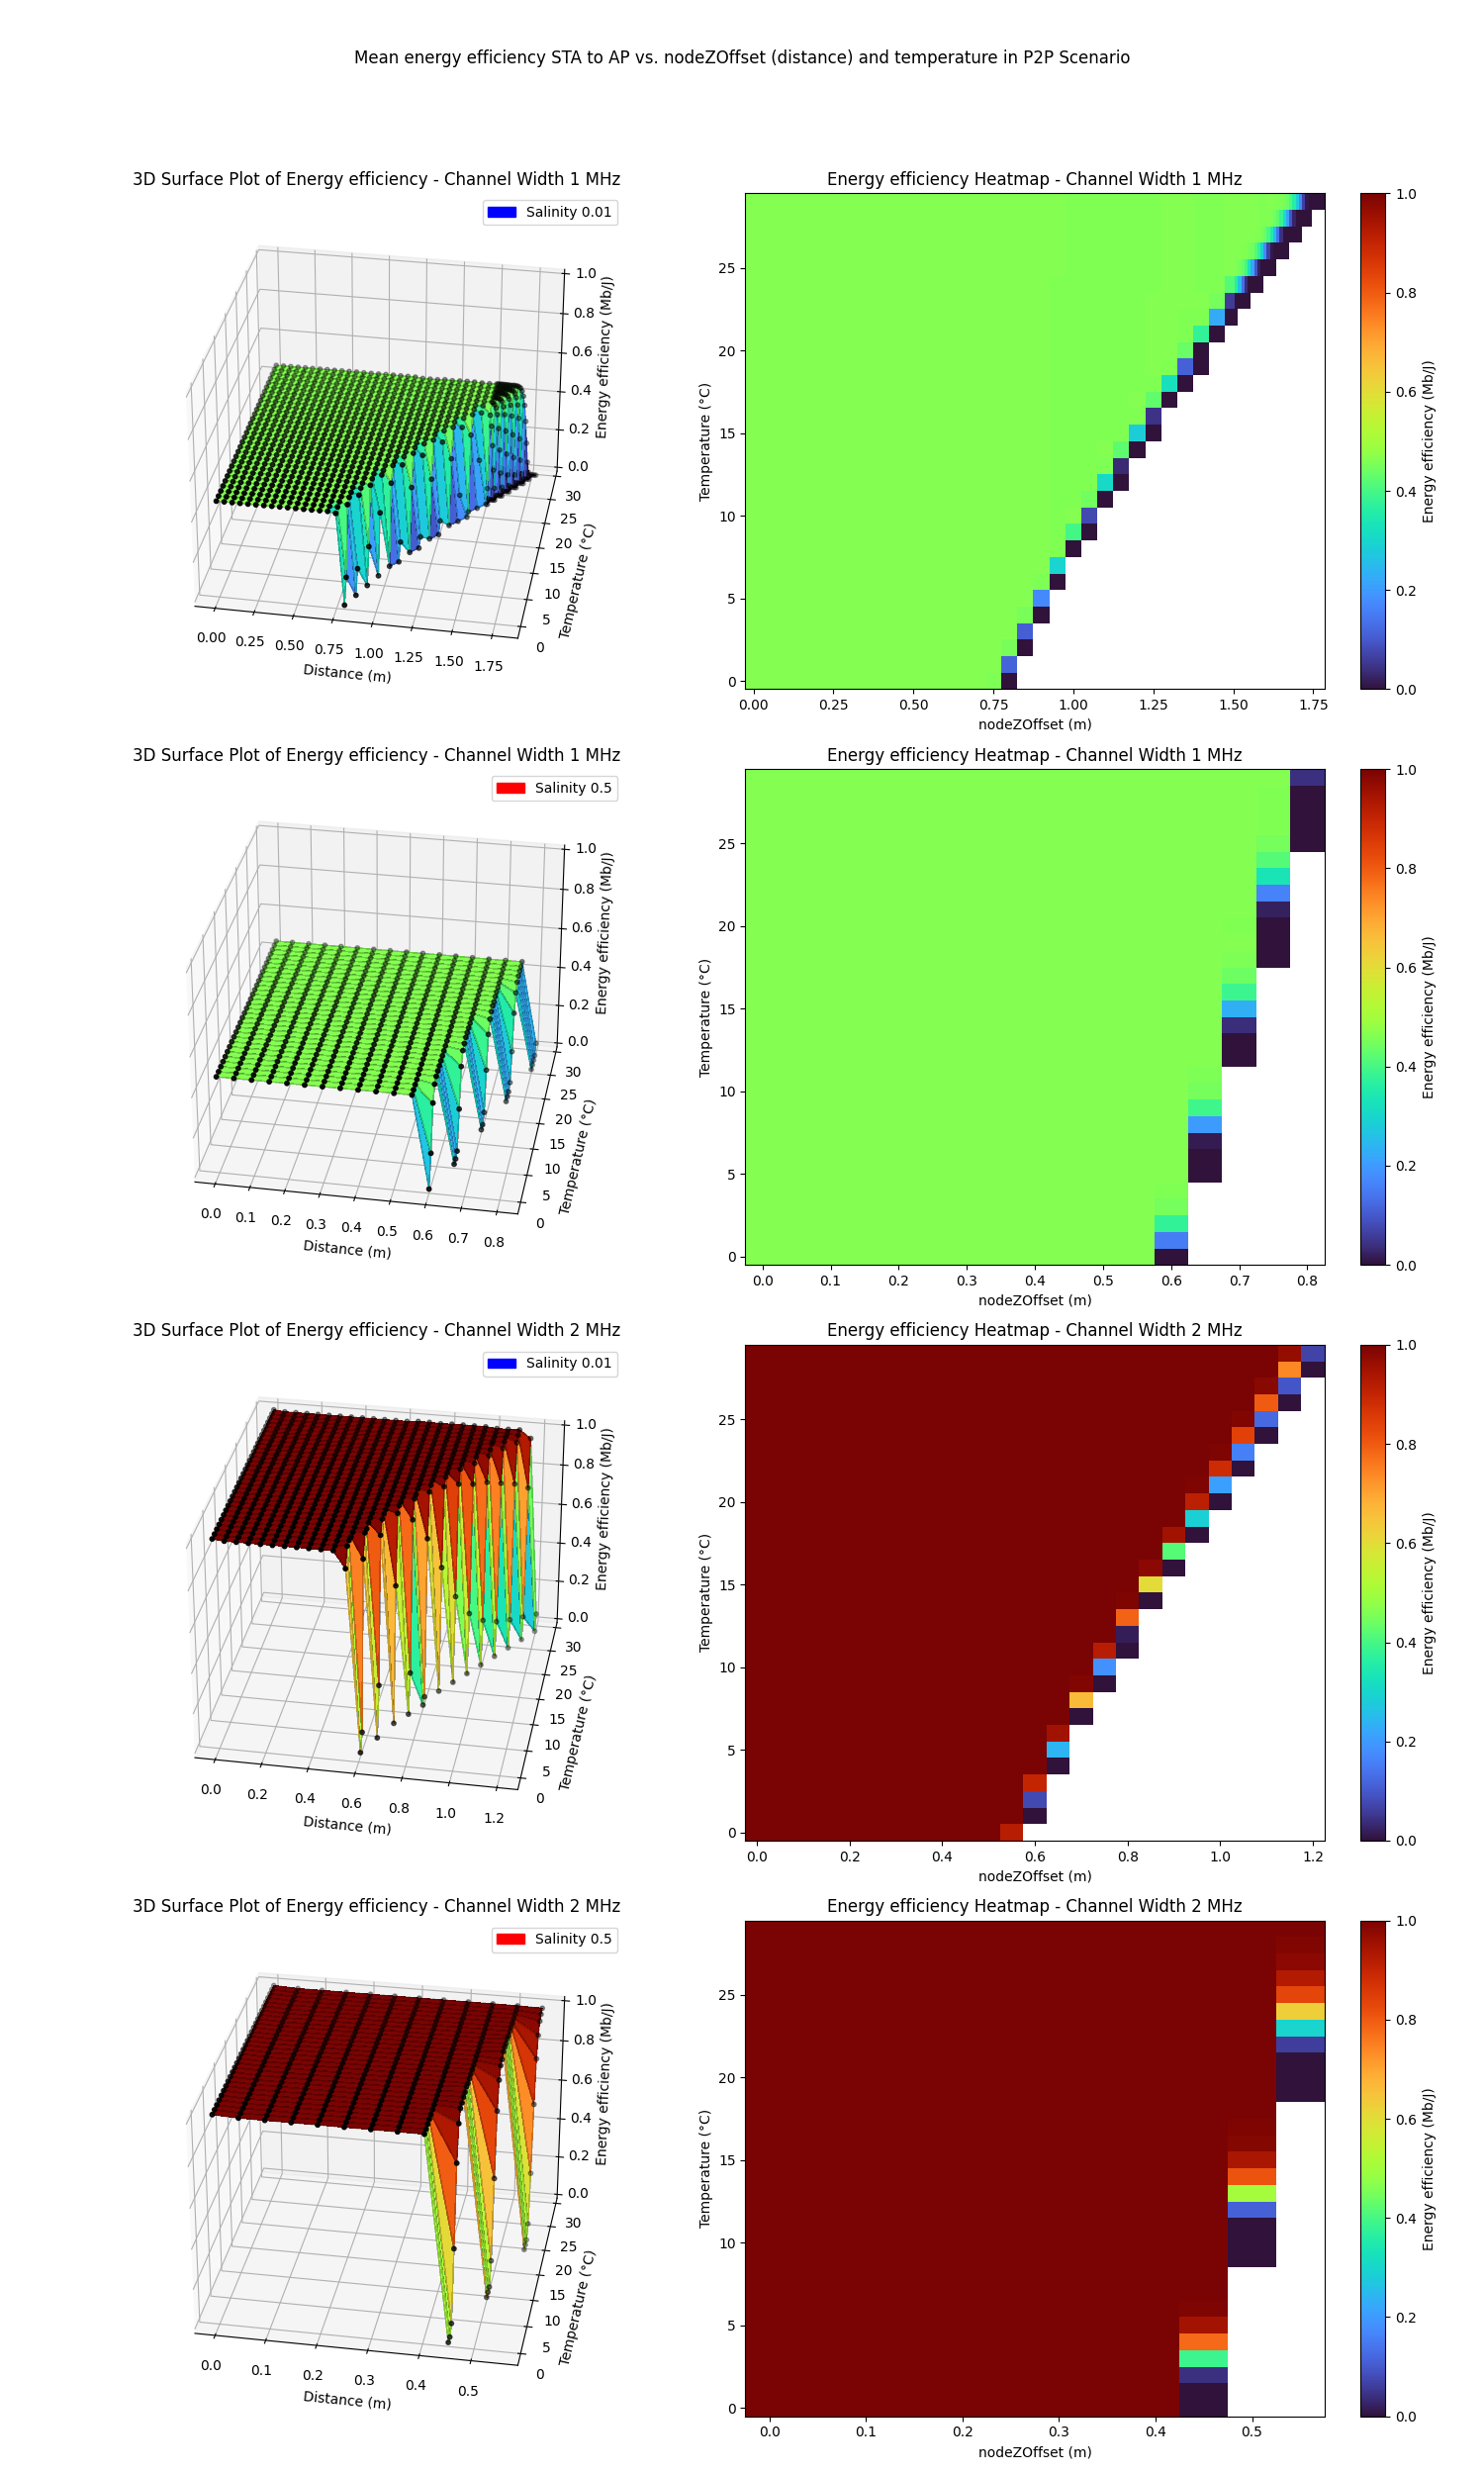

In [12]:
fig = plt.figure(figsize=(15, 25))
fig.suptitle('Mean energy efficiency STA to AP vs. nodeZOffset (distance) and temperature in P2P Scenario')

# Get unique values for each channel width and salinity
channel_widths = [1, 2]
salinity_values = [0.01, 0.5]

# Create a colormap for differentiating salinity
colors = ['blue', 'red']

# Process each channel width
for c_idx, channel_width in enumerate(channel_widths):
    # Filter data for this channel width
    filtered_data = merged_stats[merged_stats['channelWidth'] == channel_width]
    
    # Plot each salinity value
    for s_idx, salinity in enumerate(salinity_values):

        #ax = fig.add_subplot(2, 2, 2*(c_idx + 1) - s_idx, projection='3d')
        ax = fig.add_subplot(4, 2, 2*s_idx + 4*c_idx + 1, projection='3d')

        # Filter data for this salinity
        salinity_data = filtered_data[filtered_data['waterSalinity'] == salinity]
        
        # Create a 2D grid for surface plot
        x_unique = np.sort(salinity_data['nodeXOffset'].unique())
        y_unique = np.sort(salinity_data['waterTemperature'].unique())
        
        X, Y = np.meshgrid(x_unique, y_unique)
        Z = np.full(X.shape, np.inf)  # Changed from np.zeros

        missing = []
        
        # Map data to grid
        for i_x in range(len(x_unique)):
            for i_y in range(len(y_unique)):
                node_x_offset = x_unique[i_x]
                node_temperature = y_unique[i_y]
                mask = (salinity_data['nodeXOffset'] == node_x_offset) & \
                    (salinity_data['waterTemperature'] == node_temperature)
                if mask.any():
                    Z[i_y, i_x] = salinity_data.loc[mask, 'EnergyEfficiency'].mean()
                    if np.isnan(Z[i_y, i_x]):
                        print(f"{node_temperature}, {node_x_offset} is a NaN, which implies that something is wrong with the data")
                    else:
                        Z[i_y, i_x] = Z[i_y, i_x] * 1e-6
                else:
                    print(f"missing pair: {node_x_offset}, {node_temperature}, which implies that the simulation failed or didn't run (FlowMonitor file non-existent)")
                    Z[i_y, i_x] = np.nan
                    missing.append((node_x_offset, node_temperature))

        print("Number of nans", np.isnan(Z).sum())  # Count NaNs

        # print("offset_shape", salinity_data['nodeXOffset'].shape)
        # print("temperature shape", salinity_data['waterTemperature'].shape)
        # print("Z shape", Z.shape)

        # # Convert missing pairs to a temporary DataFrame
        # if missing:
        #     missing_df = pd.DataFrame({
        #         'nodeXOffset': [x for x, y in missing],
        #         'waterTemperature': [y for x, y in missing],
        #         'TotalPower': np.nan  # Fill with NaN or a default value
        #     })
        #     # Append to salinity_data (creates a new DataFrame)
        #     salinity_data = pd.concat([salinity_data, missing_df], ignore_index=True)



        # Isometric view (default 3D view)
        print(f'rendering {c_idx + 1}')
        surf1 = ax.plot_surface(X, Y, Z, cmap='turbo',
                    edgecolor=(0,0,0,0.2),  # Lighter edges
                    linewidth=0.5,  # Thinner lines
                    antialiased=False,
                    shade=True,  # Enable shading
                    alpha=1,
                    label=f'Salinity {salinity}',
                    vmin= 0,
                    vmax= 1)   # For smoother surface

        ax.view_init(elev=30, azim=-80)
        # Add labels and title
        ax.set_xlabel('Distance (m)')
        ax.set_ylabel('Temperature (°C)')
        ax.set_zlabel('Energy efficiency (Mb/J)')
        ax.set_title(f'3D Surface Plot of Energy efficiency - Channel Width {channel_width} MHz')
        ax.set_zlim(0, 1)


        #Overlay the actual data points
        ax.scatter(salinity_data['nodeXOffset'], 
                   salinity_data['waterTemperature'],
                   salinity_data['EnergyEfficiency'] * 1e-6,
                   color='black', s=10, label='Data Points')  # s = marker size

        
        # Add a legend
        # Hack to create a legend for the surfaces
        # Create proxy artists for legend
        proxy_artists = [plt.Rectangle((0, 0), 1, 1, color=colors[s_idx])]
        ax.legend(proxy_artists, [f'Salinity {salinity}' ], loc='upper right')
        #ax.legend(proxy_artists, [f'Salinity {salinity}'], loc='upper right')

        # --- 2D Heatmap ---
        ax2 = fig.add_subplot(4, 2, 2*s_idx + 4*c_idx + 2)  # Right side for 2D heatmap
        # Calculate edges halfway between centers
        x_edges = np.concatenate([
            [x_unique[0] - np.diff(x_unique)[0]/2],  # Left edge of first bin
            x_unique[:-1] + np.diff(x_unique)/2,      # Midpoints between centers
            [x_unique[-1] + np.diff(x_unique)[-1]/2]  # Right edge of last bin
        ])
        y_edges = np.concatenate([
            [y_unique[0] - np.diff(y_unique)[0]/2],
            y_unique[:-1] + np.diff(y_unique)/2,
            [y_unique[-1] + np.diff(y_unique)[-1]/2]
        ])

        # Create meshgrid for edges
        X_edges, Y_edges = np.meshgrid(x_edges, y_edges)

        heatmap = ax2.pcolormesh(
            X_edges,  # Grid edges (x-axis)
            Y_edges,  # Grid edges (y-axis)
            Z,  
            cmap='turbo',
            shading='flat',  # Smooths irregular grids
            antialiased= False,
            edgecolors='black',  # Avoids gaps between cells
            linewidth=0,
            vmin= 0,
            vmax= 1,
            rasterized= True
        )

        ax2.set_xlabel("nodeZOffset (m)")
        ax2.set_ylabel("Temperature (°C)")
        ax2.set_title(f'Energy efficiency Heatmap - Channel Width {channel_width} MHz')
        plt.colorbar(heatmap, ax=ax2, label='Energy efficiency (Mb/J)')


        # Overlay the actual data points on the heatmap
        # Ensure 'x' and 'y' values are compatible with the grid from X and Y meshgrid

        #Overlay the actual data points
        # mask = (
        #     np.isfinite(salinity_data['EnergyEfficiency'])
        # )
        # ax2.scatter(
        #     salinity_data.loc[mask,'nodeXOffset'],  # Filtered X values
        #     salinity_data.loc[mask, 'waterTemperature'],  # Filtered Y values 
        #     s=10, 
        #     label='Data Points'
        # )

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave room for suptitle
plt.show()
fig.savefig("P2P_Energy_Efficiency_graphs.svg", format="svg", dpi=300)